## Question 1: Find SST and Chlorophyll datasets over Gulf of Maine.  

In [1]:
from erddapy.multiple_server_search import search_servers


df = search_servers(
    query="SST",
    parallel=True,
    protocol="griddap",
)

In [2]:
df

,Title,Institution,Dataset ID,Server url
0,"HadISST Average Sea Surface Temperature, 1\u00...",Met Office Hadley Centre,erdHadISST,https://coastwatch.pfeg.noaa.gov/erddap/
1,"HadISST Average Sea Surface Temperature, 1\u00...",Met Office Hadley Centre,erdHadISST_Lon0360,https://coastwatch.pfeg.noaa.gov/erddap/
2,"HadISST SST state-space components Monthly, 18...","Met Office, Hadley Centre for Climate Research",erdHadISSTDecomp,https://coastwatch.pfeg.noaa.gov/erddap/
3,"HadISST SST state-space components Monthly, 18...","Met Office, Hadley Centre for Climate Research",erdHadISSTDecomp_Lon0360,https://coastwatch.pfeg.noaa.gov/erddap/
4,"HadISST Sea Ice Component, 1\u00b0;, Global, M...",Met Office Hadley Centre,erdHadISSTIce,https://coastwatch.pfeg.noaa.gov/erddap/
...,...,...,...,...
1762,Relative Bycatch:Target Catch Probability Prod...,NOAA NMFS SWFSC ERD,ecocast,https://oceanview.pfeg.noaa.gov/erddap/
1763,"C-HARM v3, 1-Day Forecast, Pseudo-nitzschia, c...","NOAA/NMFS/SWFSC/ERD, CoastWatch West Coast",wvcharmV3_1day,https://oceanview.pfeg.noaa.gov/erddap/
1764,"C-HARM v3, 2-Day Forecast, Pseudo-nitzschia, c...","NOAA/NMFS/SWFSC/ERD, CoastWatch West Coast",wvcharmV3_2day,https://oceanview.pfeg.noaa.gov/erddap/
1765,"C-HARM v3, 3-Day Forecast, Pseudo-nitzschia, c...","NOAA/NMFS/SWFSC/ERD, CoastWatch West Coast",wvcharmV3_3day,https://oceanview.pfeg.noaa.gov/erddap/


https://mathewbiddle.github.io/search-erddaps/#search=SST+Multi-scale+Ultra-high+Resolution

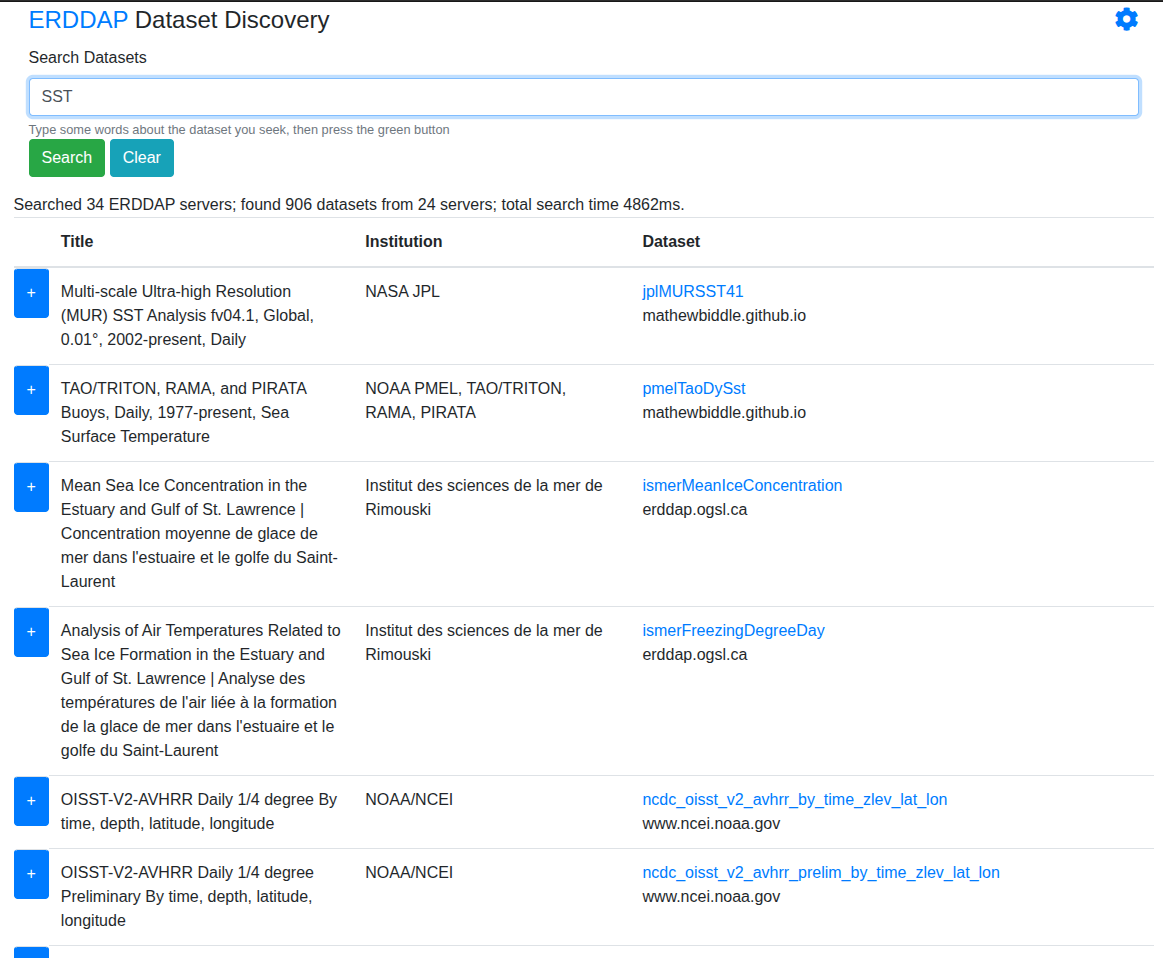

In [3]:
mask = []
for title in df["Title"]:
    if "Multi-scale Ultra-high Resolution" in title:
        mask.append(True)
    else:
        mask.append(False)

In [4]:
df.loc[mask]

,Title,Institution,Dataset ID,Server url
141,Multi-scale Ultra-high Resolution (MUR) SST An...,NOAA NMFS SWFSC ERD and NOAA NESDIS CoastWatch...,jplMURSST41anom1day,https://coastwatch.pfeg.noaa.gov/erddap/
142,Multi-scale Ultra-high Resolution (MUR) SST An...,NOAA NMFS SWFSC ERD and NOAA NESDIS CoastWatch...,jplMURSST41anom1day_Lon0360,https://coastwatch.pfeg.noaa.gov/erddap/
143,Multi-scale Ultra-high Resolution (MUR) SST An...,NOAA NMFS SWFSC ERD and NOAA NESDIS CoastWatch...,jplMURSST41anommday,https://coastwatch.pfeg.noaa.gov/erddap/
144,Multi-scale Ultra-high Resolution (MUR) SST An...,NOAA NMFS SWFSC ERD and NOAA NESDIS CoastWatch...,jplMURSST41anommday_Lon0360,https://coastwatch.pfeg.noaa.gov/erddap/
145,Multi-scale Ultra-high Resolution (MUR) SST An...,NASA JPL,jplMURSST41,https://coastwatch.pfeg.noaa.gov/erddap/
146,Multi-scale Ultra-high Resolution (MUR) SST An...,NASA JPL,jplMURSST41_Lon0360,https://coastwatch.pfeg.noaa.gov/erddap/
147,Multi-scale Ultra-high Resolution (MUR) SST An...,NASA JPL,jplMURSST41F,https://coastwatch.pfeg.noaa.gov/erddap/
148,Multi-scale Ultra-high Resolution (MUR) SST An...,NASA JPL,jplMURSST41F_Lon0360,https://coastwatch.pfeg.noaa.gov/erddap/
149,Multi-scale Ultra-high Resolution (MUR) SST An...,NOAA ERD and CoastWatch West Coast Regional Node,jplMURSST41mday,https://coastwatch.pfeg.noaa.gov/erddap/
150,Multi-scale Ultra-high Resolution (MUR) SST An...,NOAA ERD and CoastWatch West Coast Regional Node,jplMURSST41mday_Lon0360,https://coastwatch.pfeg.noaa.gov/erddap/


In [5]:
set(df.loc[mask]["Server url"])

{'https://coastwatch.noaa.gov/erddap/',
 'https://coastwatch.pfeg.noaa.gov/erddap/',
 'https://erddap.emodnet.eu/erddap/',
 'https://oceanview.pfeg.noaa.gov/erddap/',
 'https://polarwatch.noaa.gov/erddap/',
 'https://spraydata.ucsd.edu/erddap/',
 'https://upwell.pfeg.noaa.gov/erddap/'}

In [6]:
from pathlib import Path
from erddapy import ERDDAP
import xarray as xr


server = "https://coastwatch.pfeg.noaa.gov/erddap"

xmin, xmax, ymin, ymax = -71.25, -64.36, 40.90, 44.83
start = "2026-05-23"
end = "2026-05-24"

e = ERDDAP(
    server=server,
    protocol="griddap",
)


if not Path("sst.nc").exists():
    e.dataset_id = "jplMURSST41"
    e.variables  = ["analysed_sst"]

    e.constraints["time>="] = start
    e.constraints["time<="] = end
    e.constraints["latitude>="] = ymin
    e.constraints["latitude<="] = ymax
    e.constraints["longitude>="] = xmin
    e.constraints["longitude<="] = xmax

    sst = e.to_xarray()
    sst.to_netcdf("sst.nc")
else:
    sst = xr.open_dataset("sst.nc")

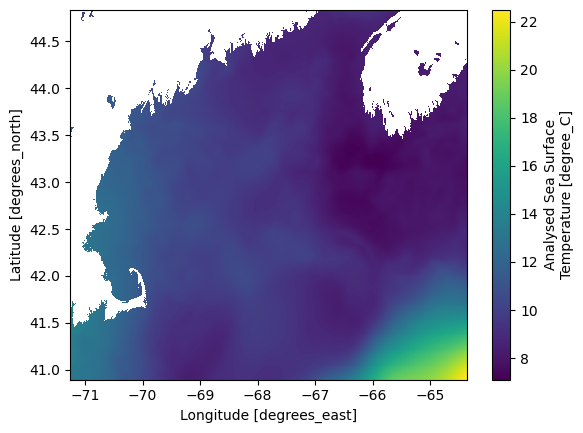

In [7]:
cs = sst["analysed_sst"].mean(dim="time").plot()

In [8]:
from erddapy import ERDDAP


if not Path("chlor_a.nc").exists():
    e.dataset_id = "nesdisVHNnoaaSNPPnoaa20NRTchlaGapfilledDaily"
    e.variables  = ["chlor_a"]

    e.constraints["time>="] = start
    e.constraints["time<="] = end
    e.constraints["latitude>="] = ymin
    e.constraints["latitude<="] = ymax
    e.constraints["longitude>="] = xmin
    e.constraints["longitude<="] = xmax

    chla = e.to_xarray()
    chla.to_netcdf("chlor_a.nc")
else:
    chla = xr.open_dataset("chlor_a.nc")

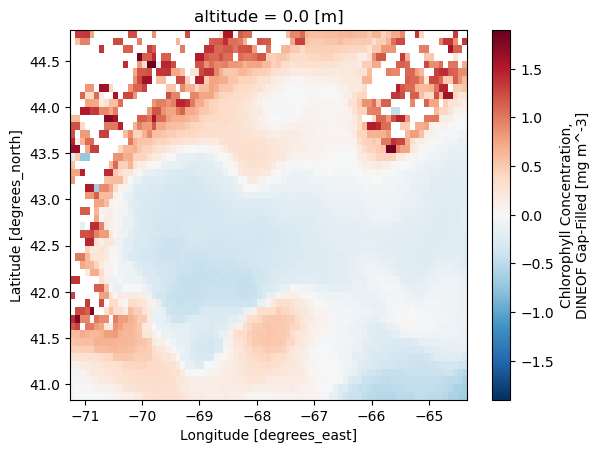

In [9]:
import numpy as np


logc = np.log10(chla["chlor_a"])
cs = logc.mean(dim="time").plot()

## Question 2: Past 7 days of glider data for the West Coast.

In [10]:
import datetime as dt
from gliderpy import GliderDataFetcher


end = dt.datetime(2026, 5, 23, tzinfo=dt.timezone.utc)
start = end - dt.timedelta(days=7)
xmin, xmax, ymin, ymax = -130.55, -117.23, 32.63, 48.95

glider_grab = GliderDataFetcher()

df = glider_grab.query(
    min_lat=ymin,
    max_lat=ymax,
    min_lon=xmin,
    max_lon=xmax,
    min_time=start,
    max_time=end,
)

df

,Title,Institution,Dataset ID,info_url
0,ce_1153-20260226T1945,OOI Coastal Endurance,ce_1153-20260226T1945,https://gliders.ioos.us/erddap/info/ce_1153-20...
1,gp_380-20250523T1827,OOI Coastal & Global Scale Nodes (CGSN),gp_380-20250523T1827,https://gliders.ioos.us/erddap/info/gp_380-202...
2,sg266-20260313T0916,Oregon State University,sg266-20260313T0916,https://gliders.ioos.us/erddap/info/sg266-2026...
3,sp013-20260303T1711,Scripps Institution of Oceanography,sp013-20260303T1711,https://gliders.ioos.us/erddap/info/sp013-2026...
4,sp055-20260225T2146,Scripps Institution of Oceanography,sp055-20260225T2146,https://gliders.ioos.us/erddap/info/sp055-2026...
5,sg272-20260203T1845,University of Washington Applied Physics Labor...,sg272-20260203T1845,https://gliders.ioos.us/erddap/info/sg272-2026...
6,sp020-20260519T1816,Scripps Institution of Oceanography,sp020-20260519T1816,https://gliders.ioos.us/erddap/info/sp020-2026...
7,sp036-20251119T1927,Scripps Institution of Oceanography,sp036-20251119T1927,https://gliders.ioos.us/erddap/info/sp036-2025...
8,sp041-20260415T1703,Scripps Institution of Oceanography,sp041-20260415T1703,https://gliders.ioos.us/erddap/info/sp041-2026...
9,sp058-20260310T1609,Scripps Institution of Oceanography,sp058-20260310T1609,https://gliders.ioos.us/erddap/info/sp058-2026...


In [11]:
from gliderpy.fetchers import GliderDataFetcher


glider_grab = GliderDataFetcher()
glider_grab.dataset_ids = df["Dataset ID"].tolist()

dfs = glider_grab.to_pandas()

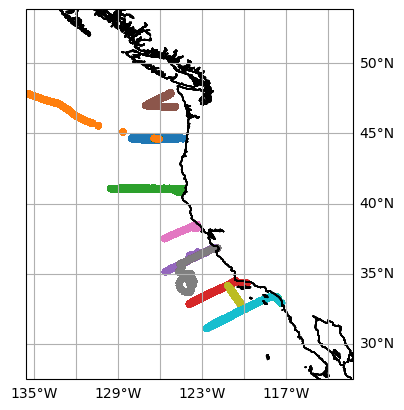

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})

for dataset_id, glider in dfs.items():
    dfs[dataset_id].plot_track(ax=ax)

dx = dy = 5
ax.set_extent(
    [
        xmin-dx,
        xmax+dx,
        ymin-dy,
        ymax+dy,
    ]
)

gl = ax.gridlines(draw_labels=True)
gl.left_labels = gl.top_labels = False